<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/codigo_unico_2002_2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#!pip install pmdarima prophet
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pmdarima as pm
from prophet import Prophet
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import os # Import the os module


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.5 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Load the Excel file into a DataFrame named df
df = pd.read_excel('/content/drive/MyDrive/0_ATALHOS/Tatiana_Ecologia_Aplicada.lnk/Shared - Mestrado Tatiana /Dados /df_curto.xlsx')

In [12]:
df

,Ano,Estado,Municipio,RDO_RPU
0,2002,AC,Acrelândia,NaN
1,2002,AC,Assis Brasil,NaN
2,2002,AC,Brasiléia,NaN
3,2002,AC,Bujari,NaN
4,2002,AC,Capixaba,NaN
...,...,...,...,...
102769,2022,TO,Tocantinópolis,18948.9
102770,2022,TO,Tupirama,280.0
102771,2022,TO,Tupiratins,100.0
102772,2022,TO,Wanderlândia,2444.0


In [13]:
municipios_por_estado = df.groupby('Estado')['Municipio'].nunique().reset_index()
municipios_por_estado.columns = ['Estado', 'Numero de Municipios']

In [14]:
municipios_por_estado

,Estado,Numero de Municipios
0,AC,22
1,AL,100
2,AM,62
3,AP,16
4,BA,295
5,CE,147
6,DF,1
7,ES,79
8,GO,245
9,MA,124


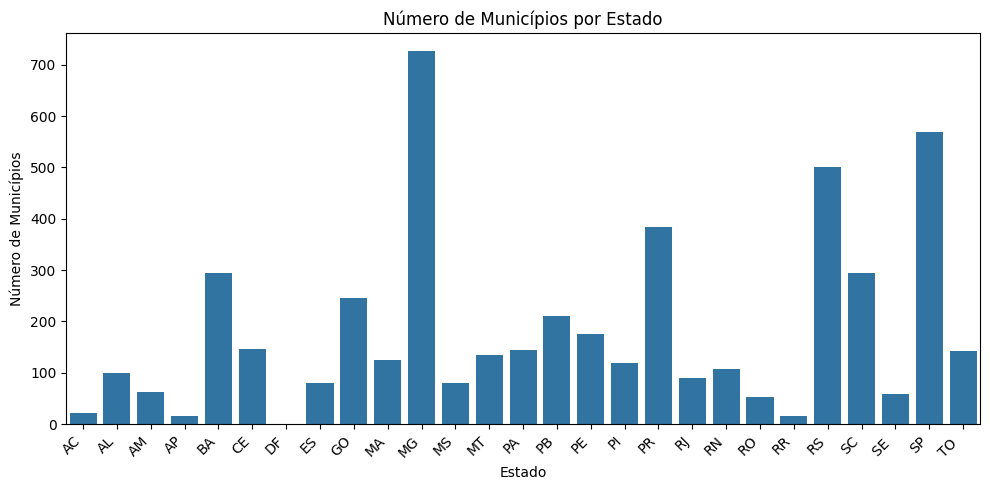

In [15]:
# Grafico de barras do municipios_por_estado
plt.figure(figsize=(10, 5))
sns.barplot(x='Estado', y='Numero de Municipios', data=municipios_por_estado)
plt.title('Número de Municípios por Estado')
plt.xlabel('Estado')
plt.ylabel('Número de Municípios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
missing_data_summary = df.groupby(['Estado', 'Municipio'])['RDO_RPU'].agg(
    total_rows='size',
    missing_count=lambda x: x.isnull().sum(),
    complete_count=lambda x: x.count()
).reset_index()

missing_data_summary

,Estado,Municipio,total_rows,missing_count,complete_count
0,AC,Acrelândia,21,19,2
1,AC,Assis Brasil,21,15,6
2,AC,Brasiléia,21,10,11
3,AC,Bujari,21,11,10
4,AC,Capixaba,21,14,7
...,...,...,...,...,...
4889,TO,Tocantínia,21,10,11
4890,TO,Tupirama,21,11,10
4891,TO,Tupiratins,21,10,11
4892,TO,Wanderlândia,21,14,7


In [17]:
#Estado = 'AL'
Numero_Dados_Completos = 21

subconjunto = missing_data_summary[
   # (missing_data_summary['Estado'] == Estado) &
    (missing_data_summary['complete_count'] >= Numero_Dados_Completos)
]
display(subconjunto[['Estado', 'Municipio', 'complete_count']])

,Estado,Municipio,complete_count
66,AL,Maceió,21
159,AM,Manaus,21
491,BA,Vitória da Conquista,21
642,DF,Brasília,21
660,ES,Colatina,21
815,GO,Goiânia,21
1152,MG,Belo Horizonte,21
1448,MG,Itabira,21
3089,RJ,Duque de Caxias,21
3651,RS,Porto Alegre,21


In [25]:
print("Realizando análise descritiva para RDO_RPU por município no subconjunto:")

# 1. Filtrar o DataFrame original 'df' com base nos pares (Estado, Municipio) presentes em 'subconjunto'
# Criar um MultiIndex a partir de subconjunto para uma busca eficiente
subconjunto_index = subconjunto.set_index(['Estado', 'Municipio']).index

# Filtrar df
df_for_plot = df[
    df.set_index(['Estado', 'Municipio']).index.isin(subconjunto_index)
].copy()

# Criar um identificador combinado para cada série para melhor representação na legenda
df_for_plot['Municipio_Estado'] = df_for_plot['Municipio'] + ' (' + df_for_plot['Estado'] + ')'

# Garantir que 'Ano' seja tratado como numérico para plotagem
df_for_plot['Ano'] = pd.to_datetime(df_for_plot['Ano'], format='%Y')

descriptive_stats = df_for_plot.groupby('Municipio_Estado')['RDO_RPU'].describe()

# Ordenar os resultados com base nos valores mínimos
descriptive_stats_sorted = descriptive_stats.sort_values(by='min', ascending=True)

# Exibir as estatísticas descritivas ordenadas
display(descriptive_stats_sorted)

Realizando análise descritiva para RDO_RPU por município no subconjunto:


,count,mean,std,min,25%,50%,75%,max
Municipio_Estado,,,,,,,,
Colatina (ES),21.0,3.010053e+04,8892.032514,1200.0,26199.0,30454.4,33401.6,50694.0
Campinas (SP),21.0,3.159121e+05,140974.721326,6499.9,248552.6,322698.0,416764.0,484734.8
Itabira (MG),21.0,2.832504e+04,8133.647123,15690.0,23712.0,25588.2,30640.3,46866.7
Vitória da Conquista (BA),21.0,6.224420e+04,12278.503312,44907.8,50275.0,63115.8,71908.3,82629.6
Maceió (AL),21.0,4.749696e+05,421321.132202,199763.5,336163.0,384960.1,504031.0,2240421.6
Duque de Caxias (RJ),21.0,4.811218e+05,477171.543329,210242.1,266753.4,353708.0,450830.0,2473918.0
Belo Horizonte (MG),21.0,9.048331e+05,320612.804350,273929.4,750162.0,812712.5,1132394.5,1690335.0
Porto Alegre (RS),21.0,7.821270e+05,367022.719343,289406.6,423598.2,961477.4,1100935.3,1279350.1
Goiânia (GO),21.0,5.108888e+05,87876.588059,387257.6,423953.0,517900.0,568561.3,698793.6


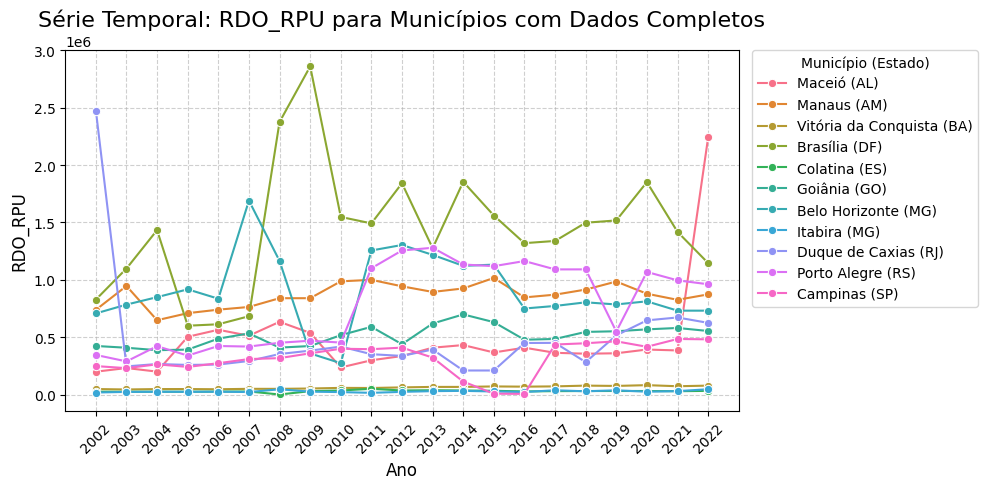

In [27]:
# 2. Criar o gráfico
plt.figure(figsize=(10, 5)) # Aumentar o tamanho da figura para acomodar mais séries
sns.lineplot(data=df_for_plot,
             x='Ano',
             y='RDO_RPU',
             hue='Municipio_Estado', # Usar o identificador combinado para a cor
             marker='o')
plt.title('Série Temporal: RDO_RPU para Municípios com Dados Completos', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('RDO_RPU', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# Ajustar o posicionamento da legenda para evitar sobreposição com o gráfico
plt.legend(title='Município (Estado)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
# Definir os ticks do eixo x para ir de 2002 a 2022, ano a ano
year_ticks = pd.to_datetime([f'{year}-01-01' for year in range(2002, 2023)])
year_labels = [str(year) for year in range(2002, 2023)]
plt.xticks(ticks=year_ticks, labels=year_labels, rotation=45)
plt.tight_layout() # Ajustar automaticamente os parâmetros do subplot para um layout apertado
plt.show()

Iniciando previsão para 11 municípios...

Processando: Maceió (AL)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


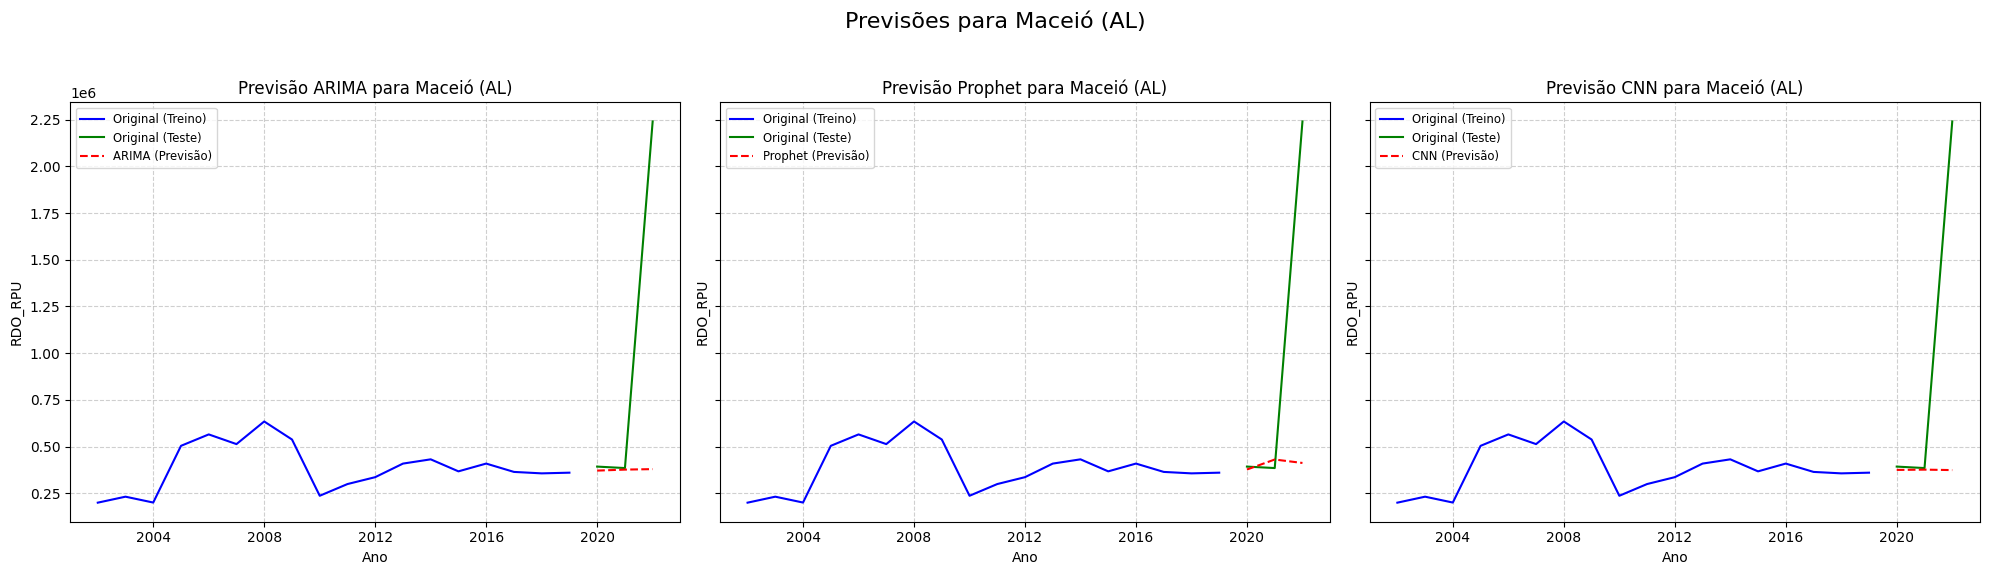


Processando: Manaus (AM)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


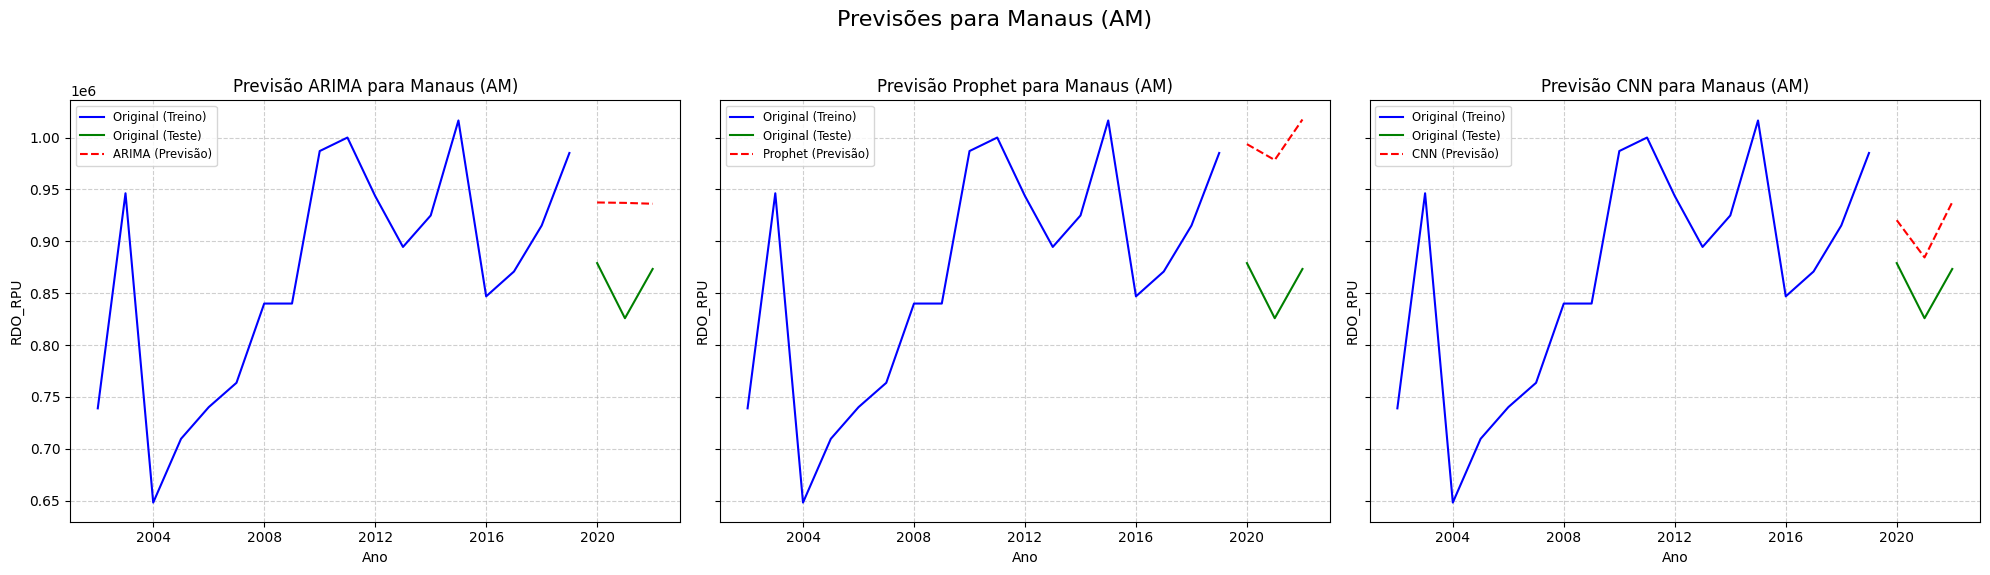


Processando: Vitória da Conquista (BA)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


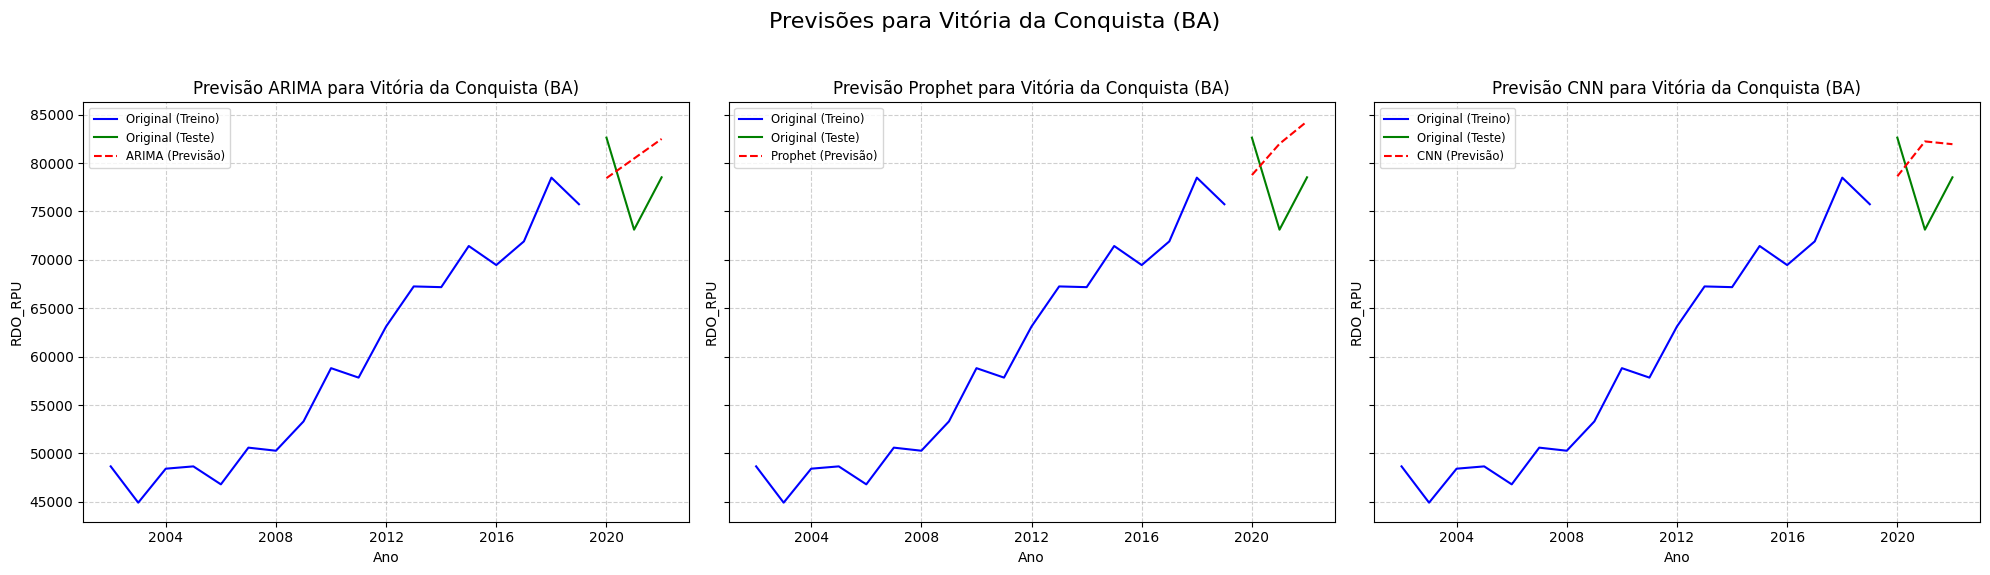


Processando: Brasília (DF)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


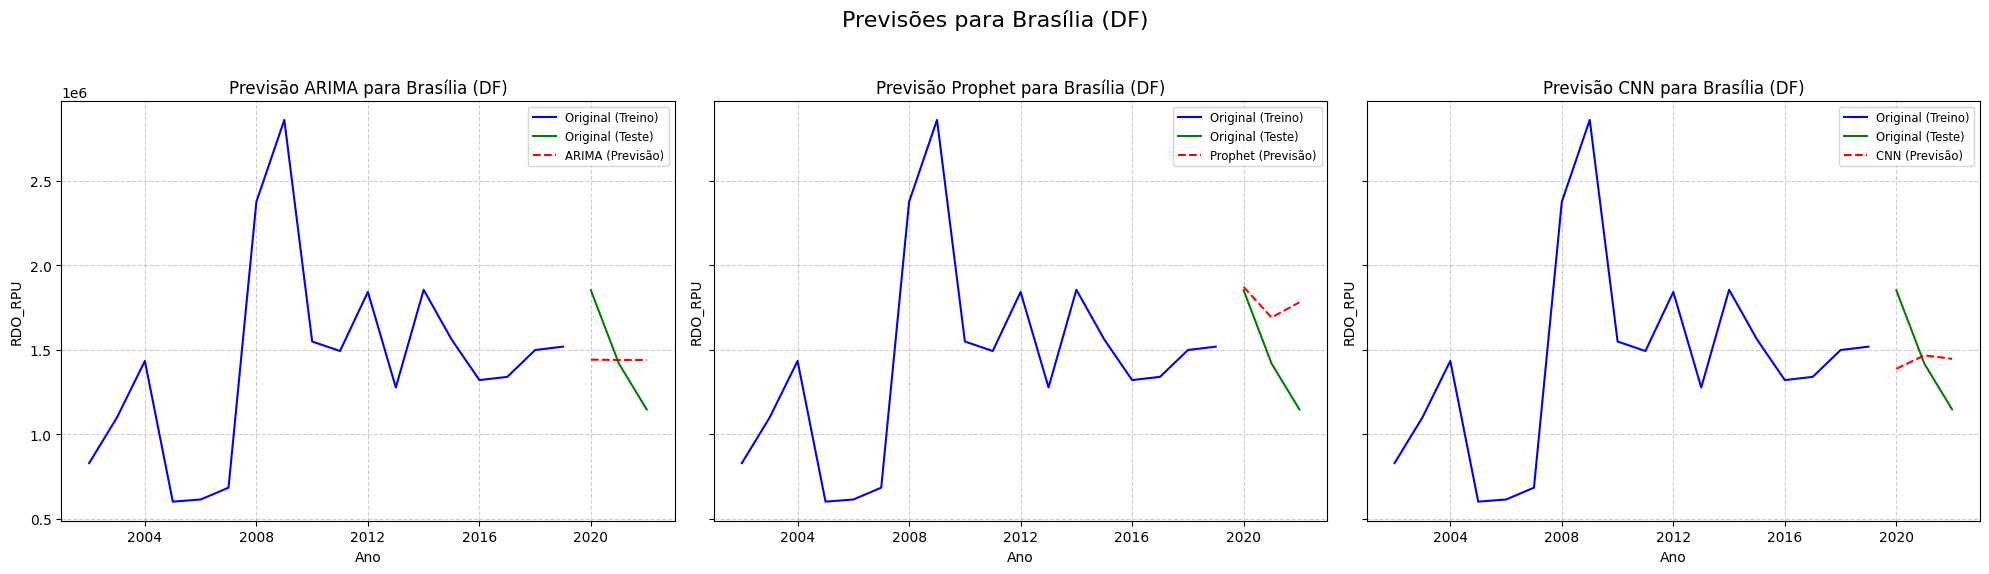


Processando: Colatina (ES)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


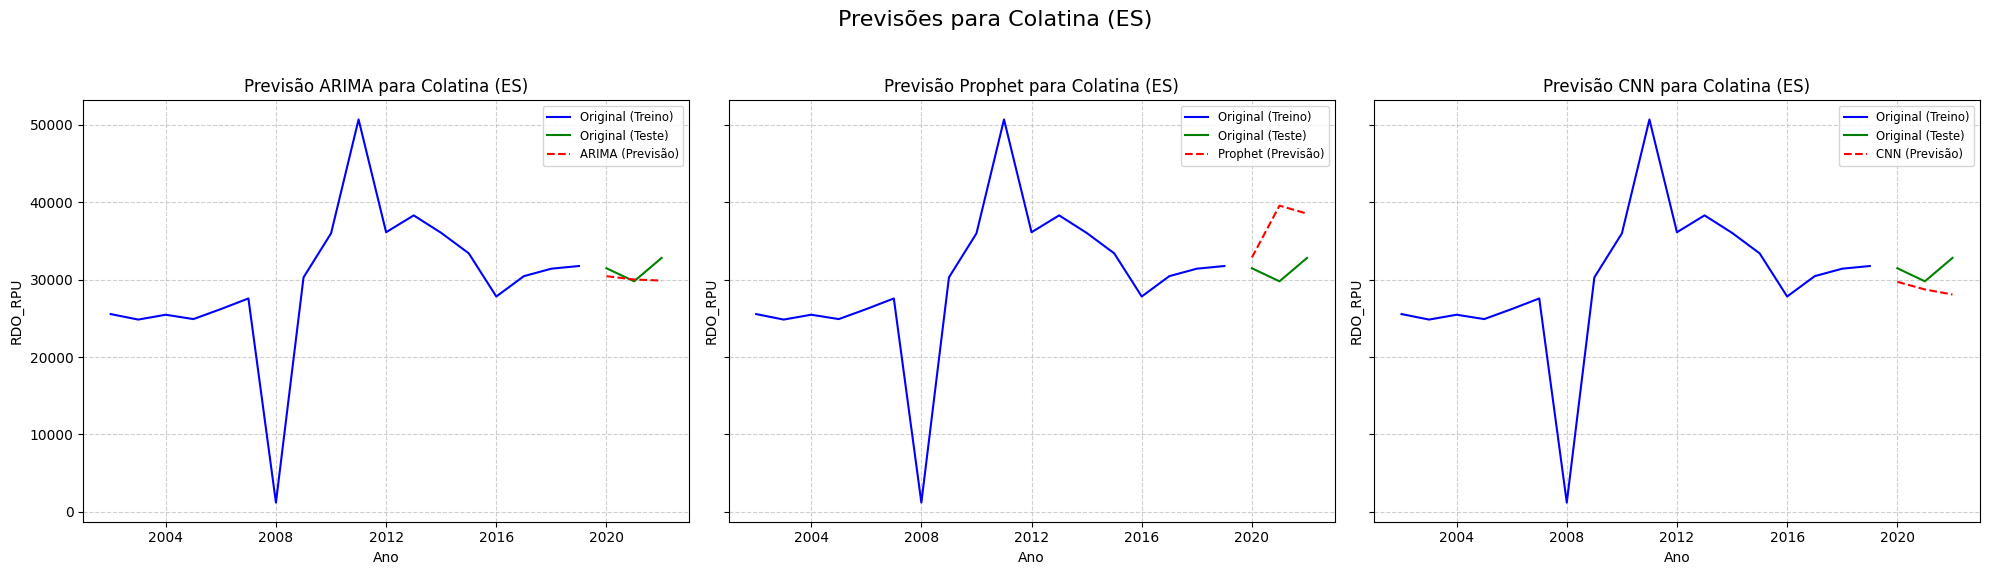


Processando: Goiânia (GO)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


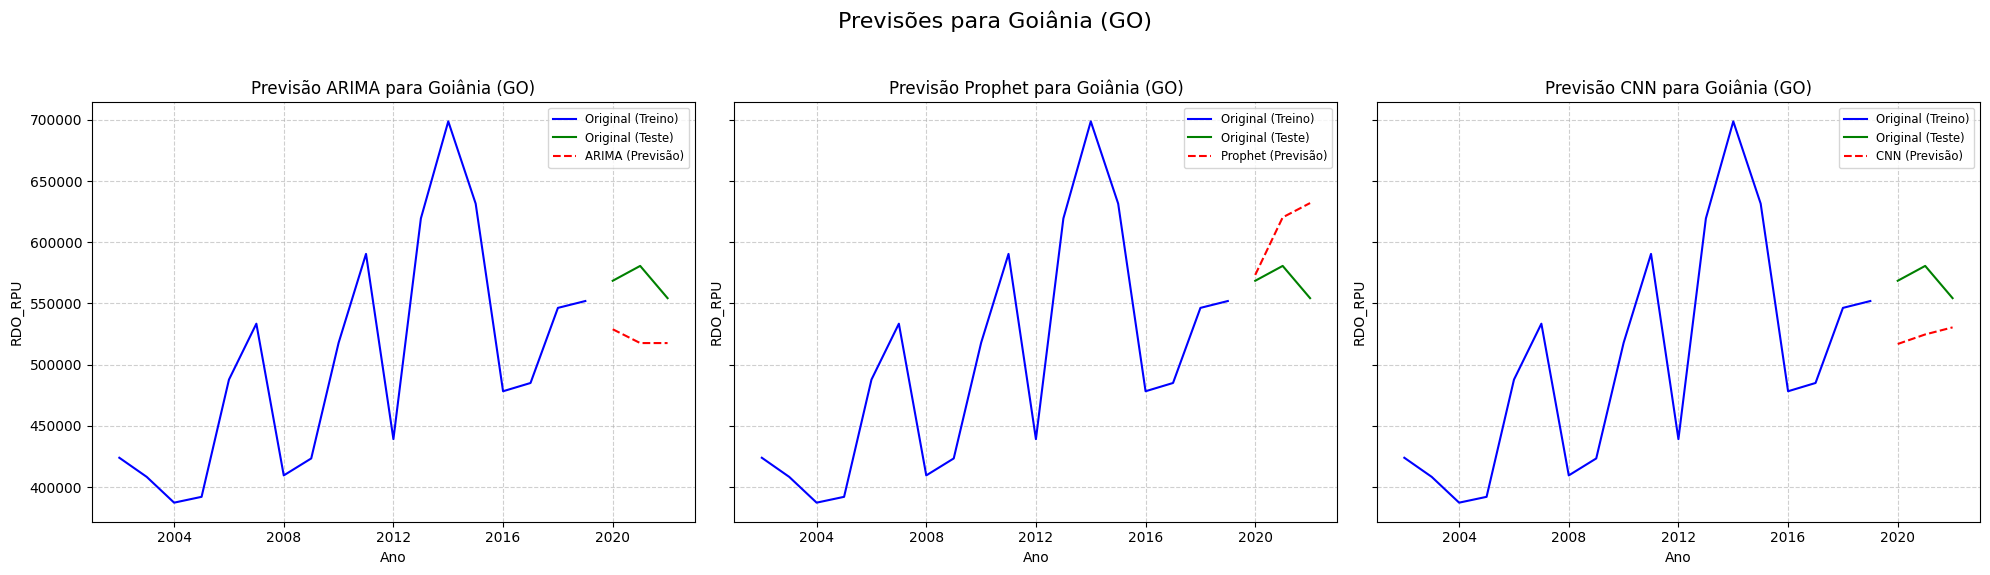


Processando: Belo Horizonte (MG)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


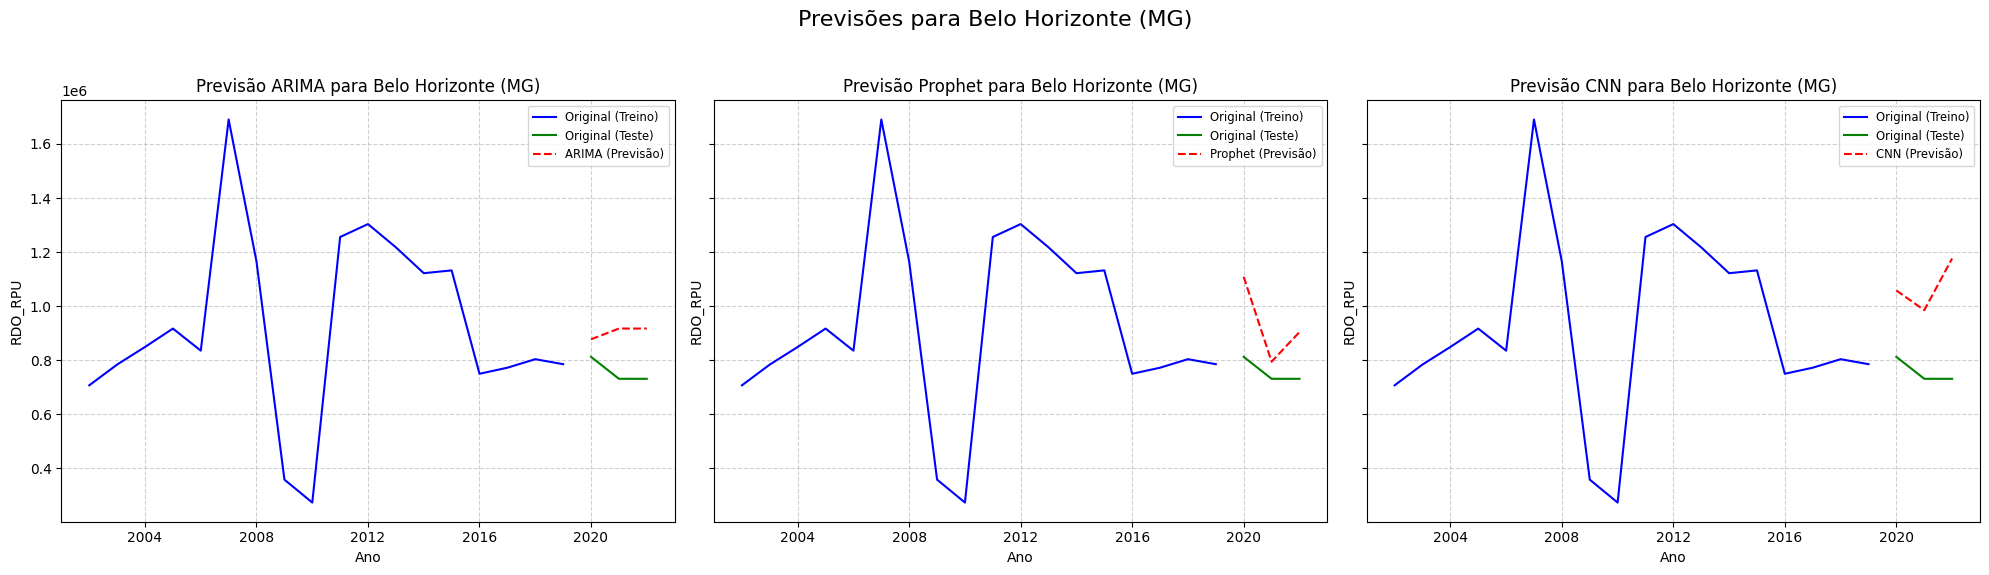


Processando: Itabira (MG)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


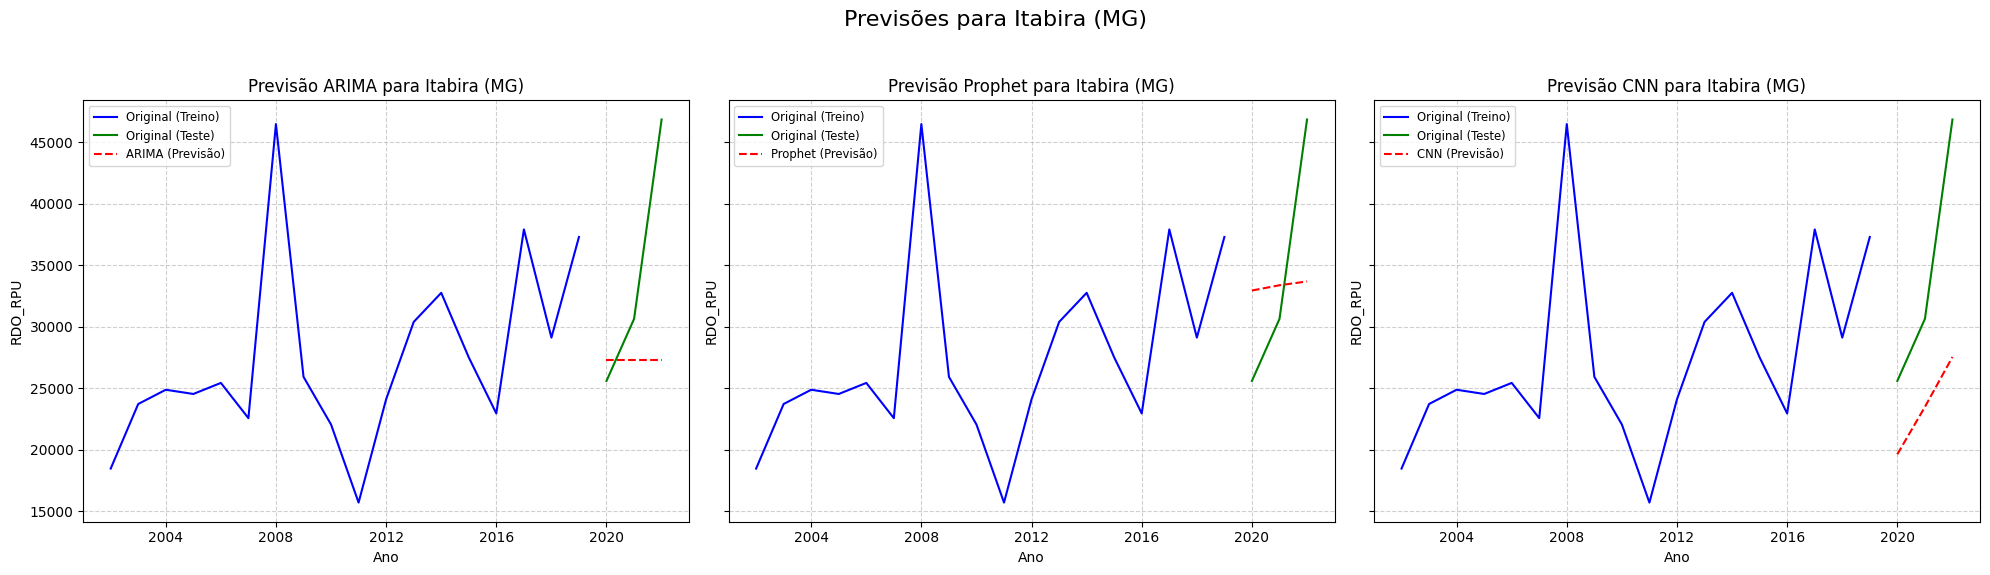


Processando: Duque de Caxias (RJ)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


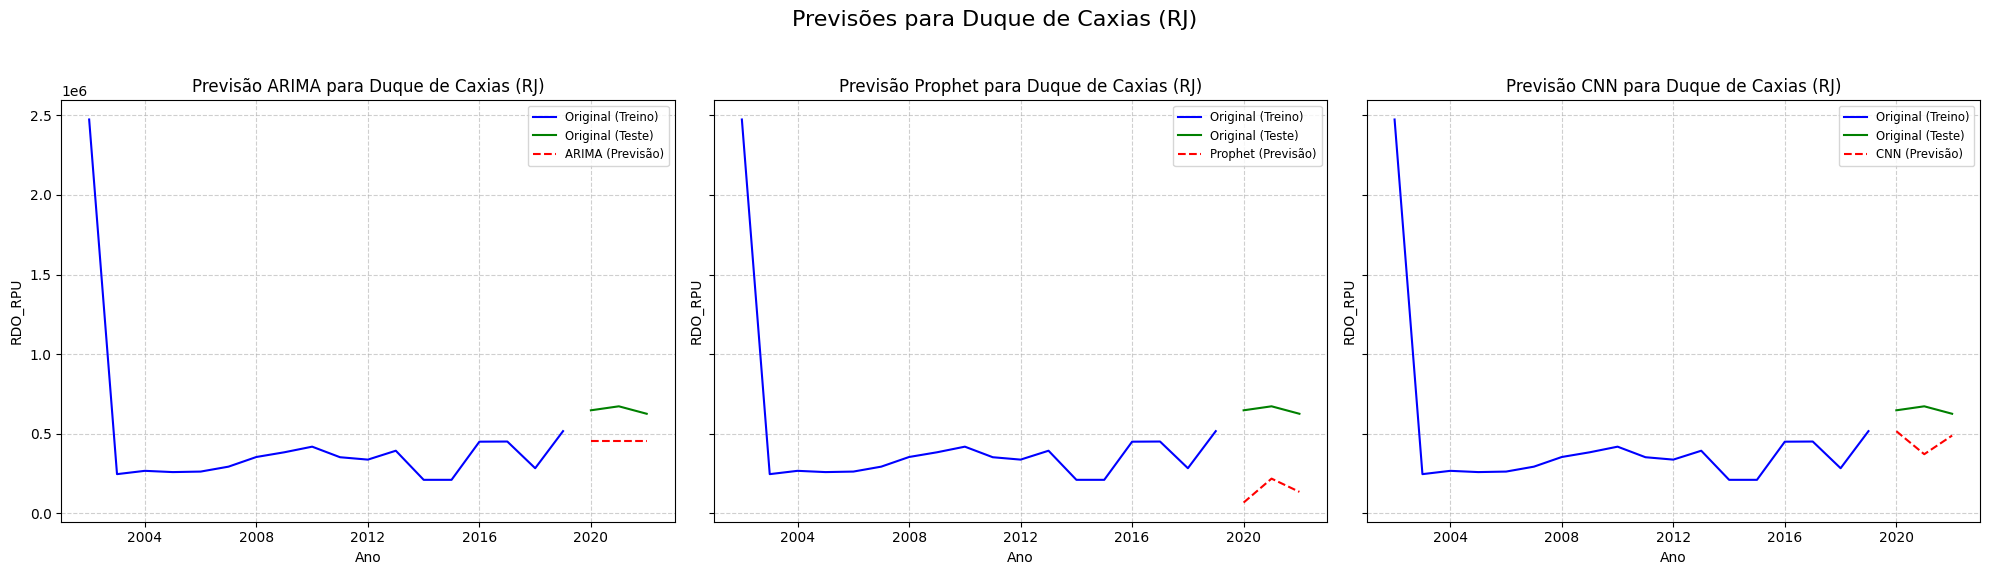


Processando: Porto Alegre (RS)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


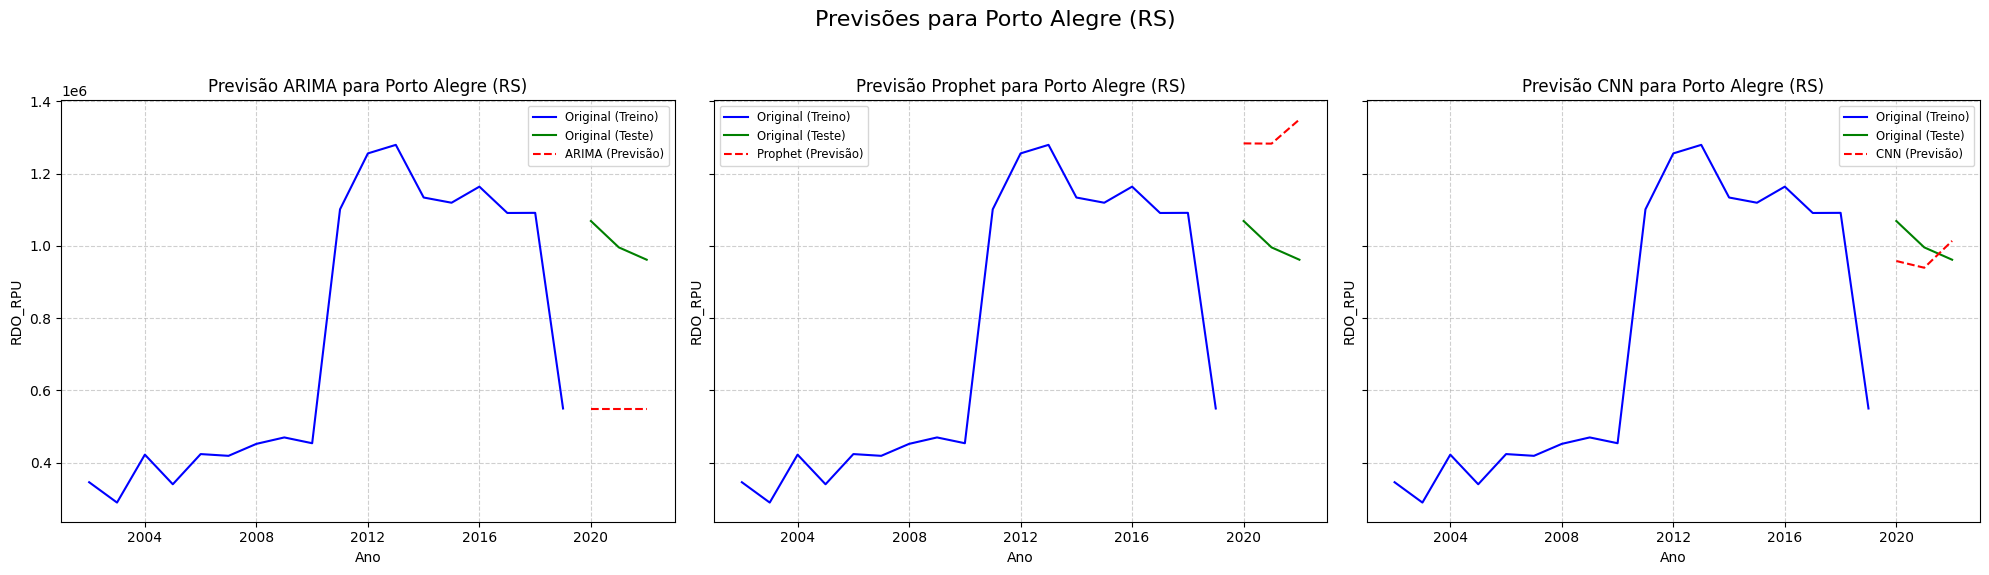


Processando: Campinas (SP)


INFO:prophet:n_changepoints greater than number of observations. Using 13.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


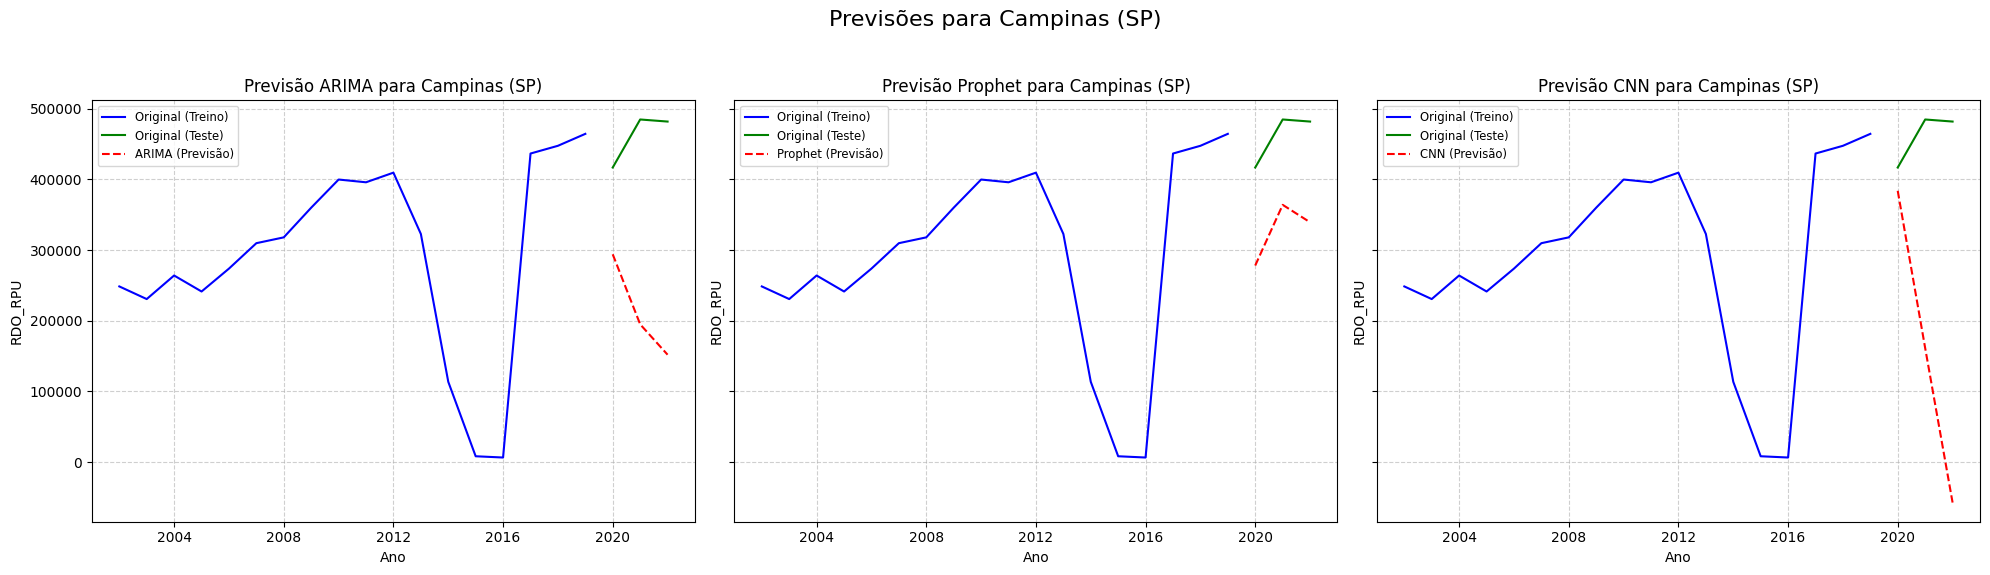


--- Comparação de Métricas de Modelos ---


,Municipio_Estado,ARIMA_RMSE,ARIMA_MAE,ARIMA_MAPE,Prophet_RMSE,Prophet_MAE,Prophet_MAPE,CNN_RMSE,CNN_MAE,CNN_MAPE
0,Maceió (AL),1.074627e+06,630302.097231,30.228866,1.055880e+06,629869.064326,32.490309,1.077598e+06,630865.202083,30.009534
1,Manaus (AM),8.107068e+04,77472.541886,9.100127,1.380080e+05,137050.359725,15.998679,5.562509e+04,54760.104167,6.388401
2,Vitória da Conquista (BA),5.394581e+03,5167.564716,6.723314,6.508430e+03,6172.767243,8.057701,6.079985e+03,5513.859375,7.223710
3,Brasília (DF),2.913600e+05,241457.199007,16.401635,3.985056e+05,308614.940200,25.194635,3.206328e+05,271018.941667,18.224370
4,Colatina (ES),1.796168e+03,1395.932341,4.323129,6.590481e+03,5630.928761,18.231107,2.970993e+03,2508.966927,7.831323
5,Goiânia (GO),4.792062e+04,46445.488882,8.146738,5.044639e+04,40722.010134,7.230370,4.609381e+04,43840.850000,7.678003
6,Belo Horizonte (MG),1.562797e+05,145498.306970,19.594638,2.013020e+05,177446.517286,22.909489,3.279062e+05,314686.408333,41.900728
7,Itabira (MG),1.149153e+04,8200.142593,19.771260,8.858588e+03,7759.462241,21.939819,1.238944e+04,10820.605078,29.317973
8,Duque de Caxias (RJ),1.957590e+05,194819.438889,29.998603,5.108589e+05,508137.929019,78.543603,2.053093e+05,189631.347917,28.975894
9,Porto Alegre (RS),4.609975e+05,458826.633333,45.387985,3.050866e+05,296694.159627,29.770450,7.774809e+04,73023.341667,7.143326


In [22]:
# Desativar warnings do TensorFlow, se houver (útil para notebooks)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Para suprimir warnings do TensorFlow

# Ensure 'df_for_plot' is available (it should be from previous cells)
# If not, the code to create it is:
# subconjunto_index = subconjunto.set_index(['Estado', 'Municipio']).index
# df_for_modeling = df[
#     df.set_index(['Estado', 'Municipio']).index.isin(subconjunto_index)
# ].copy()
# df_for_modeling['Municipio_Estado'] = df_for_modeling['Municipio'] + ' (' + df_for_modeling['Estado'] + ')'
# df_for_modeling['Ano'] = pd.to_numeric(df_for_modeling['Ano'])

# Convert 'Ano' to datetime for time series models and set as index
df_for_modeling = df_for_plot.copy() # Using df_for_plot from previous steps
df_for_modeling['Ano'] = pd.to_datetime(df_for_modeling['Ano'], format='%Y')
df_for_modeling = df_for_modeling.set_index('Ano')

# --- Helper Functions ---

def calculate_metrics(y_true, y_pred):
    """Calculates RMSE, MAE, and MAPE."""
    # Ensure y_true and y_pred are NumPy arrays for consistent operations
    y_true_np = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred_np = y_pred.values if isinstance(y_pred, pd.Series) else y_pred

    rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
    mae = mean_absolute_error(y_true_np, y_pred_np)

    # Avoid division by zero in MAPE
    y_true_no_zero = np.where(y_true_np == 0, 1e-10, y_true_np) # Replace 0 with a small number
    mape = np.mean(np.abs((y_true_np - y_pred_np) / y_true_no_zero)) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

def plot_predictions(y_train, y_test, y_pred, model_name, municipio_estado, ax):
    """Plots original, train, test, and predicted values."""
    ax.plot(y_train.index, y_train.values, label='Original (Treino)', color='blue')
    ax.plot(y_test.index, y_test.values, label='Original (Teste)', color='green')
    ax.plot(y_pred.index, y_pred.values, label=f'{model_name} (Previsão)', color='red', linestyle='--')
    ax.set_title(f'Previsão {model_name} para {municipio_estado}', fontsize=12)
    ax.set_xlabel('Ano')
    ax.set_ylabel('RDO_RPU')
    ax.legend(loc='best', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)


# --- ARIMA Model ---
def run_arima_model(series_data, municipio_estado):
    """Runs ARIMA model, predicts, plots, and returns metrics."""
    # Split data 90/10
    train_size = int(len(series_data) * 0.9)
    train, test = series_data[0:train_size], series_data[train_size:len(series_data)]

    if len(train) < 5 or len(test) < 1: # Minimum data points for auto_arima and test set
        print(f"Dados insuficientes para ARIMA em {municipio_estado} para split 90/10 ou mínimo de treino/teste.")
        return None, None

    # Find best ARIMA model (auto_arima handles hyperparameter selection)
    try:
        model = auto_arima(train, seasonal=False, suppress_warnings=True,
                           stepwise=True, trace=False, error_action='ignore')
    except Exception as e:
        print(f"Erro ao ajustar auto_arima para {municipio_estado}: {e}")
        return None, None

    # Predict
    forecast, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
    y_pred_arima = pd.Series(forecast, index=test.index)

    metrics = calculate_metrics(test, y_pred_arima)
    return y_pred_arima, metrics


# --- Prophet Model ---
def run_prophet_model(series_data, municipio_estado):
    """Runs Prophet model, predicts, plots, and returns metrics."""
    # Prophet requires 'ds' and 'y' columns
    df_prophet = pd.DataFrame({'ds': series_data.index, 'y': series_data.values})

    # Split data 90/10
    train_size = int(len(df_prophet) * 0.9)
    train_prophet, test_prophet = df_prophet[0:train_size], df_prophet[train_size:len(df_prophet)]

    if len(train_prophet) < 5 or len(test_prophet) < 1:
        print(f"Dados insuficientes para Prophet em {municipio_estado} para split 90/10 ou mínimo de treino/teste.")
        return None, None

    # Initialize and fit Prophet model (default hyperparameters are often robust)
    # Yearly seasonality is appropriate for annual data. Weekly/Daily are false.
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(train_prophet)

    # Make future dataframe for predictions
    future = m.make_future_dataframe(periods=len(test_prophet), freq='YS') # 'YS' for Year Start frequency
    forecast = m.predict(future)

    # Extract predictions for the test period
    y_pred_prophet = forecast['yhat'].iloc[train_size:].set_axis(test_prophet['ds'])

    metrics = calculate_metrics(test_prophet['y'], y_pred_prophet)
    return y_pred_prophet, metrics


# --- CNN Model ---
def run_cnn_model(series_data, municipio_estado):
    """Runs a simple CNN model, predicts, plots, and returns metrics."""

    # Scale data for neural networks
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(series_data.values.reshape(-1, 1))

    # Split data 90/10
    train_size = int(len(scaled_data) * 0.9)
    train_scaled, test_scaled = scaled_data[0:train_size], scaled_data[train_size:len(scaled_data)]

    # CNN needs a minimum number of samples for windowing (n_input) and training
    n_input = 3 # Look back 3 years to predict next
    n_features = 1

    if len(train_scaled) < n_input + 1 or len(test_scaled) < 1:
        print(f"Dados insuficientes para CNN em {municipio_estado} para split 90/10 ou janela mínima ({n_input}).")
        return None, None

    # Create TimeseriesGenerator for training
    generator = TimeseriesGenerator(train_scaled, train_scaled, length=n_input, batch_size=1)

    # Define simple CNN model
    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(n_input, n_features)),
        MaxPooling1D(pool_size=1),
        Flatten(),
        Dense(50, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # Train model
    model.fit(generator, epochs=50, verbose=0) # Set verbose to 0 to suppress output during training

    # Make predictions for the test set
    predictions = []
    # The last `n_input` points from the training set are used to start predictions
    current_batch = train_scaled[-n_input:].reshape((1, n_input, n_features))

    for i in range(len(test_scaled)):
        current_pred = model.predict(current_batch, verbose=0)[0] # Get the single prediction
        predictions.append(current_pred)
        # Update current_batch: remove the oldest value and append the new prediction
        current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

    # Inverse transform predictions and original test data
    y_pred_cnn_scaled = np.array(predictions).flatten()
    y_pred_cnn = scaler.inverse_transform(y_pred_cnn_scaled.reshape(-1, 1)).flatten()
    y_test_original = scaler.inverse_transform(test_scaled).flatten()

    y_pred_cnn_series = pd.Series(y_pred_cnn, index=series_data.index[train_size:])
    y_test_original_series = pd.Series(y_test_original, index=series_data.index[train_size:])

    metrics = calculate_metrics(y_test_original_series, y_pred_cnn_series)
    return y_pred_cnn_series, metrics


# --- Main Execution Loop ---
all_results = []
unique_municipios_estados = df_for_modeling['Municipio_Estado'].unique()

print(f"Iniciando previsão para {len(unique_municipios_estados)} municípios...")

for municipio_estado in unique_municipios_estados:
    print(f"\nProcessando: {municipio_estado}")

    municipio_data = df_for_modeling[df_for_modeling['Municipio_Estado'] == municipio_estado]['RDO_RPU']

    # Drop any NaN values that might prevent model training
    municipio_data = municipio_data.dropna()

    if len(municipio_data) < 10: # Minimum data points for meaningful time series analysis across models
        print(f"Série temporal muito curta para {municipio_estado}. Mínimo de 10 pontos necessário. Ignorando.")
        continue

    # Prepare train/test splits for plotting and metric calculation (consistent across models)
    train_size_overall = int(len(municipio_data) * 0.9)
    y_train_original = municipio_data[0:train_size_overall]
    y_test_original = municipio_data[train_size_overall:len(municipio_data)]

    if len(y_train_original) == 0 or len(y_test_original) == 0: # Ensure valid split
        print(f"Não foi possível dividir os dados de {municipio_estado} em treino e teste (90/10). Ignorando.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True) # Share Y-axis for better comparison
    fig.suptitle(f'Previsões para {municipio_estado}', fontsize=16)

    model_metrics = {'Municipio_Estado': municipio_estado}

    # ARIMA
    y_pred_arima, metrics_arima = run_arima_model(municipio_data, municipio_estado)
    if y_pred_arima is not None:
        plot_predictions(y_train_original, y_test_original, y_pred_arima, "ARIMA", municipio_estado, axes[0])
        model_metrics['ARIMA_RMSE'] = metrics_arima['RMSE']
        model_metrics['ARIMA_MAE'] = metrics_arima['MAE']
        model_metrics['ARIMA_MAPE'] = metrics_arima['MAPE']
    else:
        axes[0].text(0.5, 0.5, 'Dados insuficientes para ARIMA', transform=axes[0].transAxes,
                     horizontalalignment='center', verticalalignment='center', fontsize=10, color='red')
        axes[0].set_title(f'ARIMA para {municipio_estado}', fontsize=12)


    # Prophet
    y_pred_prophet, metrics_prophet = run_prophet_model(municipio_data, municipio_estado)
    if y_pred_prophet is not None:
        plot_predictions(y_train_original, y_test_original, y_pred_prophet, "Prophet", municipio_estado, axes[1])
        model_metrics['Prophet_RMSE'] = metrics_prophet['RMSE']
        model_metrics['Prophet_MAE'] = metrics_prophet['MAE']
        model_metrics['Prophet_MAPE'] = metrics_prophet['MAPE']
    else:
        axes[1].text(0.5, 0.5, 'Dados insuficientes para Prophet', transform=axes[1].transAxes,
                     horizontalalignment='center', verticalalignment='center', fontsize=10, color='red')
        axes[1].set_title(f'Prophet para {municipio_estado}', fontsize=12)


    # CNN
    y_pred_cnn, metrics_cnn = run_cnn_model(municipio_data, municipio_estado)
    if y_pred_cnn is not None:
        plot_predictions(y_train_original, y_test_original, y_pred_cnn, "CNN", municipio_estado, axes[2])
        model_metrics['CNN_RMSE'] = metrics_cnn['RMSE']
        model_metrics['CNN_MAE'] = metrics_cnn['MAE']
        model_metrics['CNN_MAPE'] = metrics_cnn['MAPE']
    else:
        axes[2].text(0.5, 0.5, 'Dados insuficientes para CNN', transform=axes[2].transAxes,
                     horizontalalignment='center', verticalalignment='center', fontsize=10, color='red')
        axes[2].set_title(f'CNN para {municipio_estado}', fontsize=12)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    all_results.append(model_metrics)

# Display overall metrics comparison
results_df = pd.DataFrame(all_results)
print("\n--- Comparação de Métricas de Modelos ---")
display(results_df)